I**mport the required Libraries**

In [3]:
import numpy as np
import matplotlib.pyplot as plt 

import pandas as pd  
import seaborn as sns 

%matplotlib inline

**Load the Boston Housing DataSet from scikit-learn**

In [4]:
boston = pd.read_csv("BostonHousing.csv")
boston


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [7]:
boston.columns = boston.columns.str.upper()

**Load the data into pandas dataframe**

In [8]:
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


**Data preprocessing**

In [9]:
# check for missing values in all the columns
boston.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [10]:
import seaborn as sns

In [11]:
sns.boxplot(data = boston)

<Axes: >

**Data Visualization**

C:\Users\91782\AppData\Local\Temp\ipykernel_19376\1048330251.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(boston['MEDV'], bins=30)


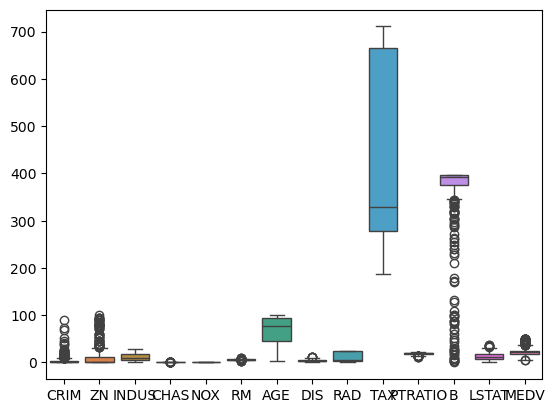

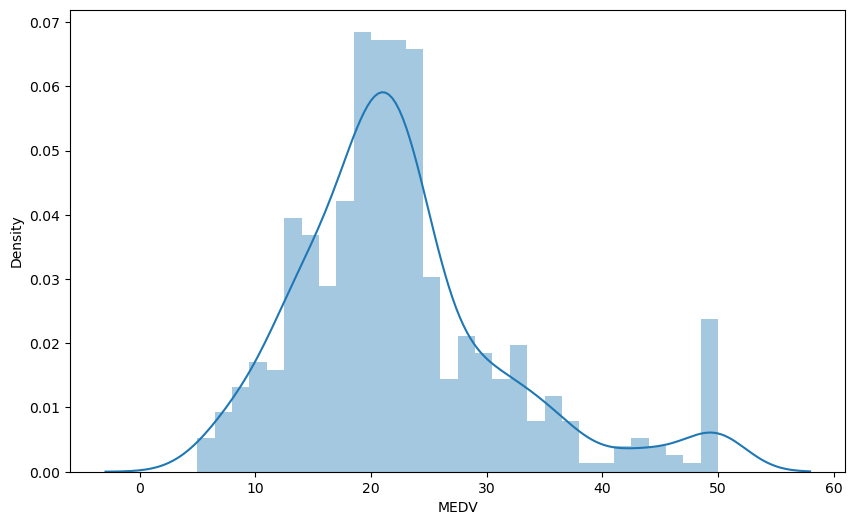

In [12]:
# set the size of the figure
plt.figure(figsize = [10, 6])

# plot a histogram showing the distribution of the target values
sns.distplot(boston['MEDV'], bins=30)
plt.show()

**Correlation matrix**

In [13]:
# compute the pair wise correlation for all columns  
correlation_matrix = boston.corr().round(2)

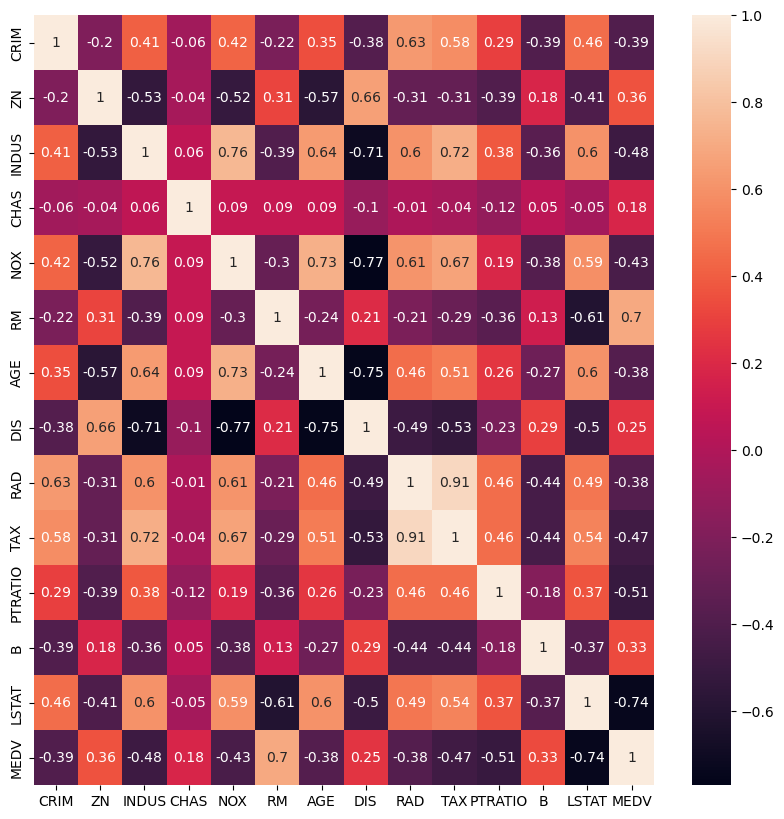

In [32]:
# use the heatmap function from seaborn to plot the correlation matrix
# annot = True to print the values inside the square
plt.figure(figsize = [10, 10])
sns.heatmap(data=correlation_matrix, annot=True)
plt.show()

**Observations**




*   From the above coorelation plot we can see that **MEDV** is strongly correlated to **LSTAT**, **RM**

*  **RAD** and **TAX** are stronly correlated, so we don't include this in our features together to avoid multi-colinearity




In [15]:
plt.figure(figsize=(20, 5))

features = ['LSTAT', 'RM']
target = boston['MEDV']

for i, col in enumerate(features):
    plt.subplot(1, len(features) , i+1)
    x = boston[col]
    y = target
    plt.scatter(x, y, marker='o')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('MEDV')

In [16]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


**Prepare the data for training**

In [17]:
output = boston['MEDV']
input = boston.drop("MEDV", axis = 1)

**Split the data into training and testing sets**

In [18]:
from sklearn.model_selection import train_test_split

# splits the training and test data set in 80% : 20%
# assign random_state to any value.This ensures consistency.
input_train, input_test, output_train, output_test = train_test_split(input, output, test_size = 0.2, random_state=5)

print(input_train.shape)
print(input_test.shape)
print(output_train.shape)
print(output_test.shape)

(404, 13)
(102, 13)
(404,)
(102,)


**Train the model using sklearn LinearRegression**

In [19]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(input_train, output_train)

LinearRegression()

In [20]:
print(lin_model.coef_)
print(lin_model.intercept_)

[-1.30799852e-01  4.94030235e-02  1.09535045e-03  2.70536624e+00
 -1.59570504e+01  3.41397332e+00  1.11887670e-03 -1.49308124e+00
  3.64422378e-01 -1.31718155e-02 -9.52369666e-01  1.17492092e-02
 -5.94076089e-01]
37.91248700975003


In [21]:
y_prediction = lin_model.predict(input_train)
y_prediction

array([13.82876985, 44.52852811,  3.91599095, 22.37795855, 18.23592252,
       25.52374759, 29.43974677, 18.69453347, 27.85646296, 24.64473374,
       20.53039645, 32.24809769, 19.53384497, 10.6751149 , 22.77616204,
       17.35106653, 18.54046999, 16.36847196, 21.72533915, 35.71120541,
       21.83662056, 19.76107221, 24.18285088, 25.5255809 , 20.8464168 ,
       24.53500383, 23.78138462, 40.86911314, 40.39520996, 29.63686507,
       12.619354  , 15.73341062, 18.21178776, 21.16340747, 16.66802114,
        5.97334491, 24.31645777, 30.41975812, 23.26407764, 19.39240148,
       16.09545573, 21.11256921, 34.44869686, 26.91553429, 30.23074628,
       18.03371864, 22.39969339, 29.3639849 , 13.012578  , 35.56341078,
       10.91286971, 13.56179599, 27.60611138, 31.30757803, 11.07295389,
       24.39197327, 28.74300261, 32.45909463, 15.73036294, 30.13719482,
        7.84896909, 34.49967116, 25.308736  , 20.0655545 , 15.24843367,
       12.43138278, 30.63133241, 16.39957657, 23.95719598, 20.73

In [22]:
np.array(output_train)

array([13.1, 50. ,  8.8, 20.6, 12.1, 50. , 24.1, 16.1, 23.9, 24.3, 13.1,
       30.3, 15.2, 13.8, 26.4, 16.6, 18.9, 17.6, 18.7, 33.4, 20.7, 17.1,
       23.4, 26.5, 21.4, 21.5, 19.2, 50. , 50. , 23. , 10.5, 17.8, 10.9,
       21. , 13.8, 10.5, 22.2, 30.5, 19.4, 15.6, 20.2, 19.3, 34.6, 50. ,
       24. , 18.7, 19.8, 22.5, 13.3, 50. , 11.8, 11. , 23.7, 35.4, 15.2,
       24.4, 33.4, 31.6, 13.4, 34.9, 14.4, 35.4, 25.3, 18.3, 16.6, 13.4,
       23.6, 27.5, 22.2, 17.7, 14.3, 21.7,  8.4, 15.3, 20.3, 32. , 20. ,
       19.1, 28.7, 46. , 22.6, 23.9, 21.9, 15.6, 50. , 25. , 37.9, 21.6,
       19.3, 17.5, 22.9, 15. , 27.5, 10.2, 23.8, 23.9, 20.1, 16.5, 33.1,
       14.6, 28.4, 23.7, 12.3, 31.5, 22. , 12.5, 35.1, 14.9, 22.9, 22.9,
       19.3, 19.8, 20. , 29.6, 20.5, 29. , 20.7, 19.9, 11.9,  5. , 23.3,
       20.6, 22.9, 19.6, 14.1, 30.8, 43.1, 19.9, 13.9, 22.3, 14.3, 23.9,
       16. , 20.5, 10.2, 20.1, 12.8, 18.9, 22. , 20.4, 17.5, 13.1, 22. ,
       45.4, 18.8, 20. , 20.1, 21.4, 17.4, 21.1, 28

In [23]:
#model evaluation

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("For Training Set")

print("MSE:", mean_squared_error(output_train, y_prediction))
print("RMSE:", np.sqrt(mean_squared_error(output_train, y_prediction)))

print("MAE:", mean_absolute_error(y_prediction, output_train))
print("MAPE:", mean_absolute_percentage_error(output_train, y_prediction))

print("r2_score:", r2_score(output_train, y_prediction))


For Training Set
MSE: 22.477090408387628
RMSE: 4.741000992236516
MAE: 3.350009519648457
MAPE: 0.16513409231463358
r2_score: 0.738339392059052


In [24]:
def calculate_mse(arr1, arr2):
    return np.mean((arr1-arr2)**2)
def calculate_mae(arr1, arr2):
    return np.mean(np.abs(arr1-arr2))

def calculate_mape(ytrue, ypred):
    return np.mean(np.abs(ypred-ytrue)/ytrue)
    
def calculate_r2_score(ytrue, ypred):
    rss = np.sum((ytrue-ypred)**2)
    tss = np.sum((ytrue-np.mean(ytrue))**2)
    return 1 - rss/tss

print(calculate_mse(output_train, y_prediction))
print(calculate_mae(output_train, y_prediction))
print(calculate_mape(output_train, y_prediction))
print(calculate_r2_score(output_train, y_prediction))




22.477090408387628
3.350009519648457
0.16513409231463358
0.738339392059052


In [25]:
y_prediction_test = lin_model.predict(input_test)

In [26]:
#model evkuation on unseen dataset
#model evaluation

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("For Testing Set")

print("MSE:", mean_squared_error(output_test, y_prediction_test))
print("RMSE:", np.sqrt(mean_squared_error(output_test, y_prediction_test)))

print("MAE:", mean_absolute_error(output_test, y_prediction_test))
print("MAPE:", mean_absolute_percentage_error(output_test, y_prediction_test))

print("r2_score:", r2_score(output_test, y_prediction_test))


For Testing Set
MSE: 20.869292183770767
RMSE: 4.568292042303203
MAE: 3.213270495842383
MAPE: 0.17232298968410104
r2_score: 0.7334492147453082


In [27]:
y_prediction_test

array([37.56311787, 32.14445143, 27.06573629,  5.67080633, 35.09982577,
        5.85803701, 27.53708506, 31.81019188, 26.35634771, 22.77208748,
       31.91183048, 21.50224061, 23.70119983, 33.3622504 , 28.51633591,
       14.39456899,  0.19284025, 18.66247155, 13.71004139, 14.13408635,
        2.03263952, 19.7280831 , 38.18657429, 24.19760058, 31.30247973,
       11.14144544, 25.03636951, 23.27970871, 22.49420127, 20.52972594,
       15.16513744,  6.92553586, 18.3557733 , 22.37179804, 28.91287973,
       19.02980786, 30.19357214,  8.74384915, 40.86691522, 34.53763591,
       20.70224878,  2.59618963, 29.99590282, 12.15704798, 27.10186397,
       30.8052437 , -6.24169079, 19.84885777, 20.92973441, 12.43523958,
       20.4949947 , 19.19231742, 23.69073157, 12.67998473, 17.14252424,
       25.04649176, 34.77758126, 15.23294903, 28.22306193, 21.08745388,
       20.39506129, 25.79476888, 14.72463673, 33.18635032, 23.17771307,
       13.11057248, 19.23154617, 24.61162961, 21.50327036, 22.00

In [28]:
input_test["medv_actual"] = output_test
input_test["medv_predicted"] = y_prediction_test

input_test

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,medv_actual,medv_predicted
226,0.38214,0.0,6.20,0,0.504,8.040,86.5,3.2157,8,307,17.4,387.38,3.13,37.6,37.563118
292,0.03615,80.0,4.95,0,0.411,6.630,23.4,5.1167,4,245,19.2,396.90,4.70,27.9,32.144451
90,0.04684,0.0,3.41,0,0.489,6.417,66.1,3.0923,2,270,17.8,392.18,8.81,22.6,27.065736
373,11.10810,0.0,18.10,0,0.668,4.906,100.0,1.1742,24,666,20.2,396.90,34.77,13.8,5.670806
273,0.22188,20.0,6.96,1,0.464,7.691,51.8,4.3665,3,223,18.6,390.77,6.58,35.2,35.099826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,0.02899,40.0,1.25,0,0.429,6.939,34.5,8.7921,1,335,19.7,389.85,5.89,26.6,21.912956
212,0.21719,0.0,10.59,1,0.489,5.807,53.8,3.6526,4,277,18.6,390.94,16.03,22.4,22.394774
156,2.44668,0.0,19.58,0,0.871,5.272,94.0,1.7364,5,403,14.7,88.63,16.14,13.1,13.193354
480,5.82401,0.0,18.10,0,0.532,6.242,64.7,3.4242,24,666,20.2,396.90,10.74,23.0,23.969911


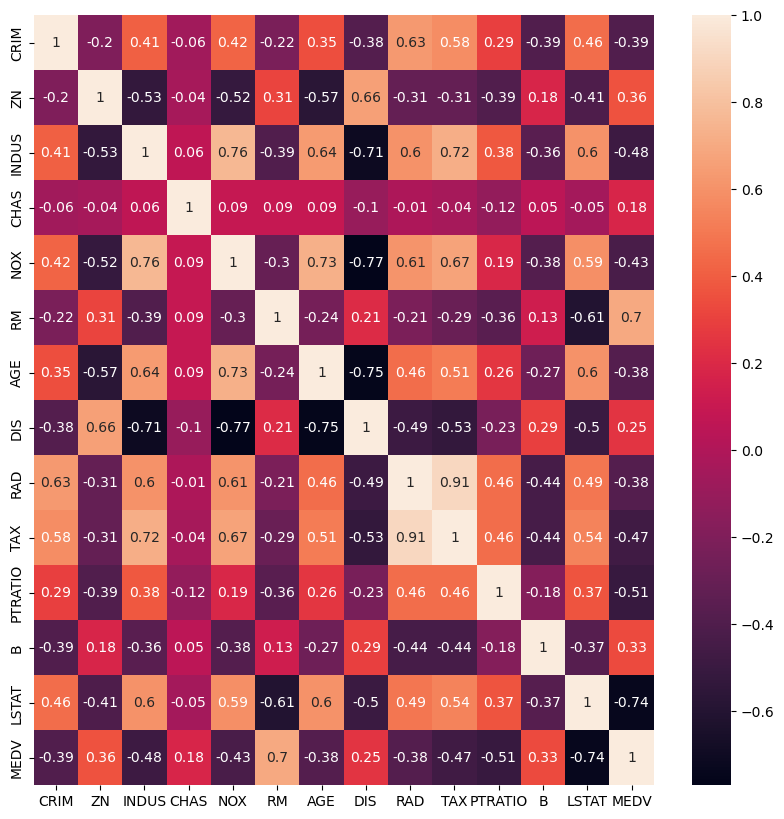

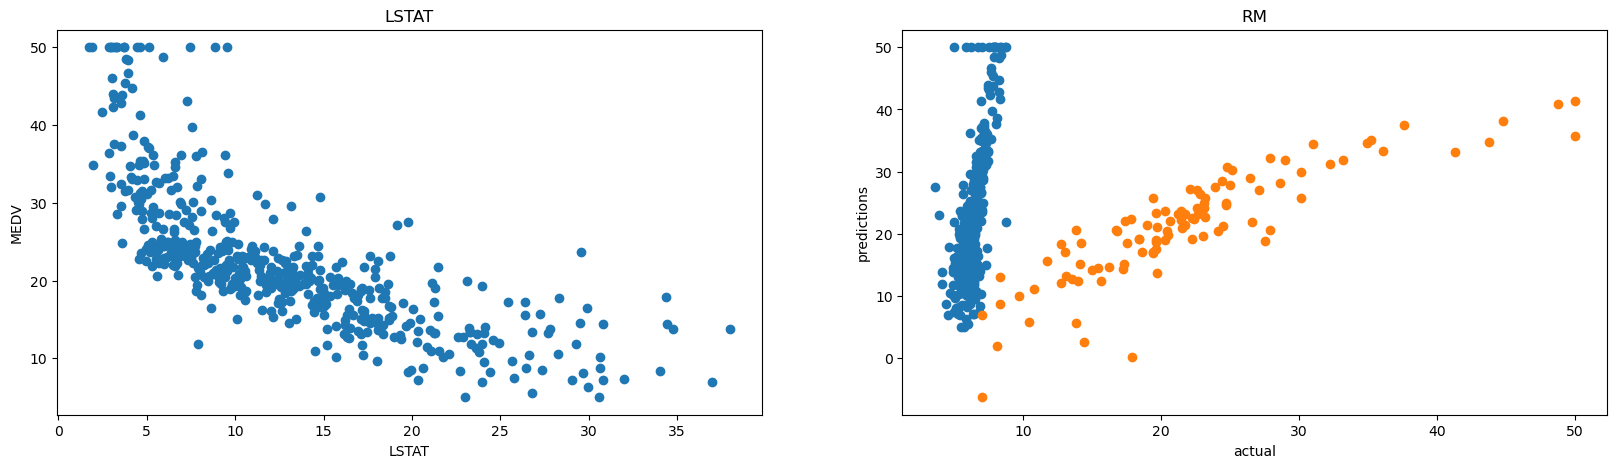

In [29]:
# plotting the y_test vs y_pred
# ideally should have been a straight line
plt.scatter(output_test, y_prediction_test)
plt.xlabel("actual")
plt.ylabel("predictions")
plt.show()

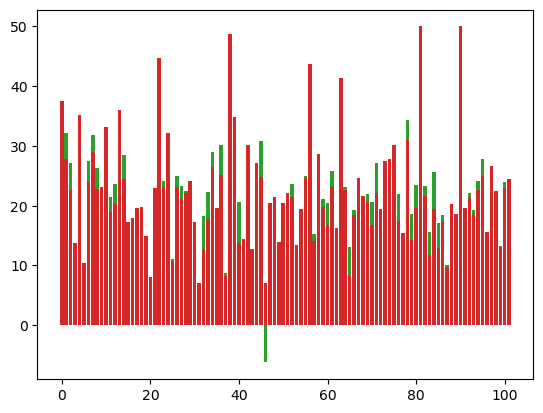

In [31]:
plt.bar([i for i in range(len(output_test))], y_prediction_test)
plt.bar([i for i in range(len(output_test))], output_test)
plt.show()

